In [1]:
import pandas as pd # type: ignore
import numpy as np
import seaborn as sns # type: ignore
import matplotlib.pyplot as plt # type: ignore
from sklearn.metrics import confusion_matrix
#columns: 
# model_id, size, instruction, dataset, framing, item_id, 
# target, prediction, raw_result, bin_result, valid, abstain

In [2]:
# types of dataframes:
df = pd.read_csv("../results/results.csv") #everything
valid_df = df[df["valid"] == 1] #doesnt punish low coverage
abstain_df = df[(df["framing"] == "framing2")] #for analysis on framing 2 specifically

label_map = {
    "long_model_name_1": "M1",
    "long_model_name_2": "M2",
    "long_model_name_3": "M3",
}

vis_df = df.copy() #will be modified to have cleaner graphs by shortening certain labels

In [3]:

vis_df["model_id"] = (
    vis_df["model_id"]
    .str[4:] # removes "qwen" as all of them have that in common
    .str.replace("instruct", "ins", regex=False)
)

vis_df["framing"] = (
    vis_df["framing"]
    .str.replace("framing", "", regex=False)
    .astype(int)
)

In [4]:
#this cell is for graphing/visual information to work

#variables:
# model_id (size, instruction if relevant), dataset, framing

#model order in data: qwen2.5_1.5b_instruct, qwen2.5_7b_instruct, qwen3_0.6b, qwen3_8B_instruct
model_palette = { # taken as two issues: ordinal(small/big), categorical (not/instruct) -> small/big = dull/saturated, not/instruct = green/red
    "qwen3_0.6b": "#3A5445",            # dull, green
    "qwen2.5_1.5b_instruct": "#653966", # dull, magenta
    "qwen3_8b": "#1ACF65",              # sat , green
    "qwen2.5_7b_instruct": "#C834C3",   # sat , magenta
    "3_0.6b": "#3A5445",            # dull, green
    "2.5_1.5b_ins": "#653966", # dull, magenta
    "3_8b": "#1ACF65",              # sat , green
    "2.5_7b_ins": "#C834C3"    # sat , magenta
}

dataset_palette = { # categorical
    "liar": "#EA4848",
    "truthseeker": "#E69627"
}

#['2.5_1.5b_ins', '2.5_7b_ins', '3_0.6b', '3_8b'], for graph space

### Analysis and Exploration

In [5]:
full_summary = (
    vis_df
    .groupby(["model_id", "dataset", "framing"])
    .agg(
        sel_acc=("bin_result", "mean"), #selective accuracy (truncated for length)
        coverage=("valid", "mean"),
        eff_acc=("effective_accuracy", "mean"), #effective accuracy
    ))
full_summary["sel_acc"] = full_summary["sel_acc"].round(4)
full_summary["coverage"] = full_summary["coverage"].round(2)
full_summary["eff_acc"] = full_summary["eff_acc"].round(4)
print(full_summary)


                                  sel_acc  coverage  eff_acc
model_id     dataset     framing                            
2.5_1.5b_ins liar        0         0.6442      1.00   0.6442
                         1         0.6405      1.00   0.6405
                         2         0.5941      0.99   0.5876
                         3         0.6259      1.00   0.6259
                         4         0.6168      1.00   0.6168
             truthseeker 0         0.5964      1.00   0.5964
                         1         0.6040      1.00   0.6040
                         2         0.6971      1.00   0.6938
                         3         0.6068      1.00   0.6068
                         4         0.6134      1.00   0.6134
2.5_7b_ins   liar        0         0.6606      1.00   0.6606
                         1         0.6861      1.00   0.6861
                         2         0.8308      0.12   0.0985
                         3         0.6642      1.00   0.6642
                        

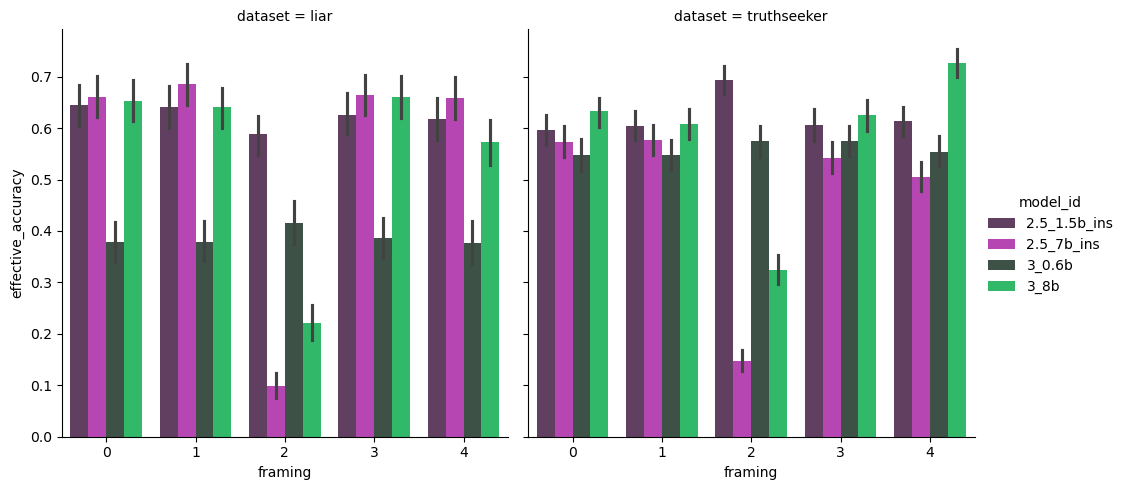

In [6]:
sns.catplot(
    data=vis_df,
    x="framing",
    y="effective_accuracy",
    hue="model_id",
    col="dataset",
    kind="bar",
    palette= model_palette
)

plt.show()

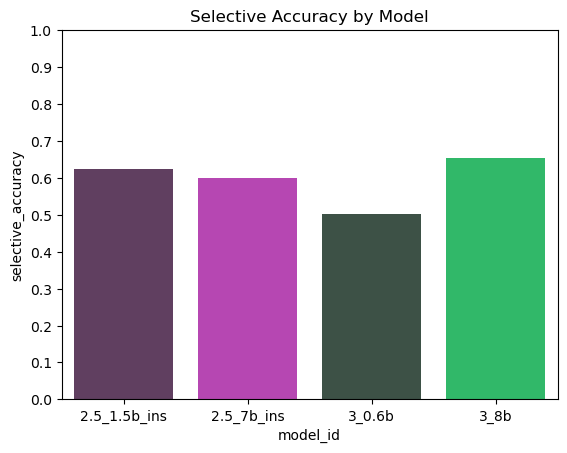

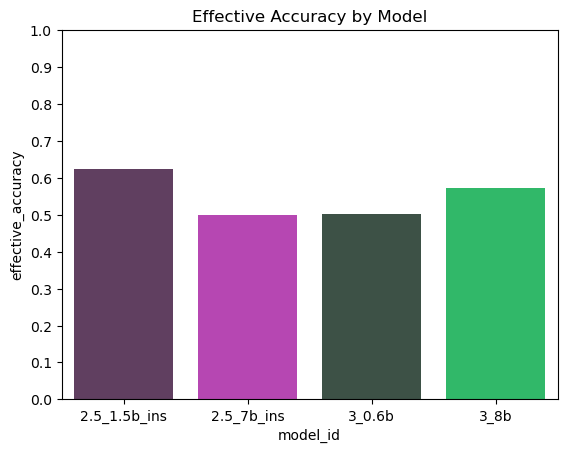

In [7]:
model_summary = (
    vis_df
    .groupby(["model_id"])
    .agg(
        selective_accuracy=("bin_result", "mean"),
        effective_accuracy=("effective_accuracy", "mean"),
    )
    .reset_index()
)


sns.barplot(
    data=model_summary,
    x="model_id",
    y="selective_accuracy",
    hue="model_id",
    palette=model_palette,
)

plt.title("Selective Accuracy by Model")
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.01, 0.1))
plt.show()

sns.barplot(
    data=model_summary,
    x="model_id",
    y="effective_accuracy",
    hue="model_id",
    palette=model_palette,
)

plt.title("Effective Accuracy by Model")
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.01, 0.1))
plt.show()

In [8]:
print(model_summary)

       model_id  selective_accuracy  effective_accuracy
0  2.5_1.5b_ins            0.623769            0.622914
1    2.5_7b_ins            0.599670            0.497883
2        3_0.6b            0.501059            0.500872
3          3_8b            0.651995            0.571856


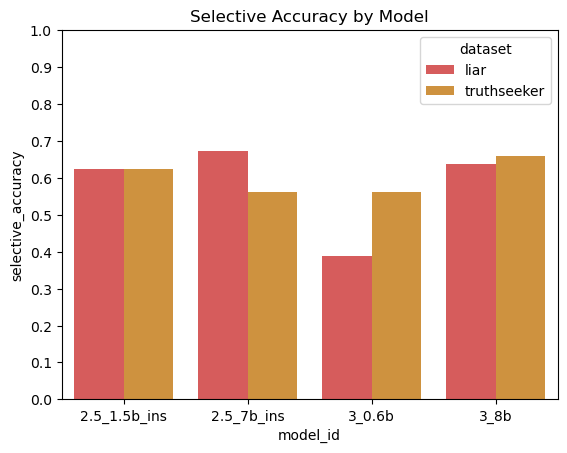

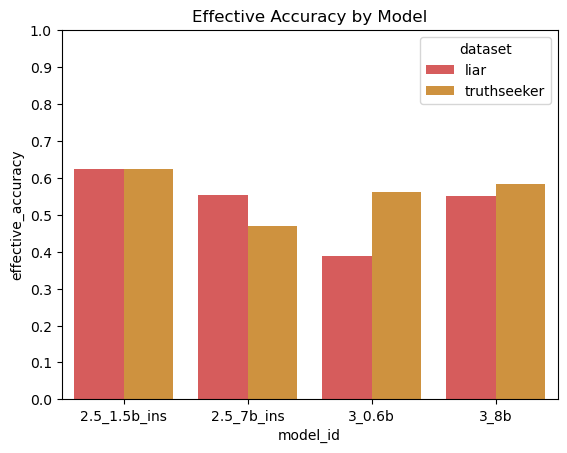

In [9]:
model_ds_summary = (
    vis_df
    .groupby(["model_id","dataset"])
    .agg(
        selective_accuracy=("bin_result", "mean"),
        effective_accuracy=("effective_accuracy", "mean"),
    )
    .reset_index()
)

sns.barplot(
    data=model_ds_summary,
    x="model_id",
    y="selective_accuracy",
    hue="dataset",
    palette=dataset_palette,
)


plt.title("Selective Accuracy by Model")
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.01, 0.1))

plt.show()


sns.barplot(
    data=model_ds_summary,
    x="model_id",
    y="effective_accuracy",
    hue="dataset",
    palette=dataset_palette,
)


plt.title("Effective Accuracy by Model")
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.01, 0.1))

plt.show()

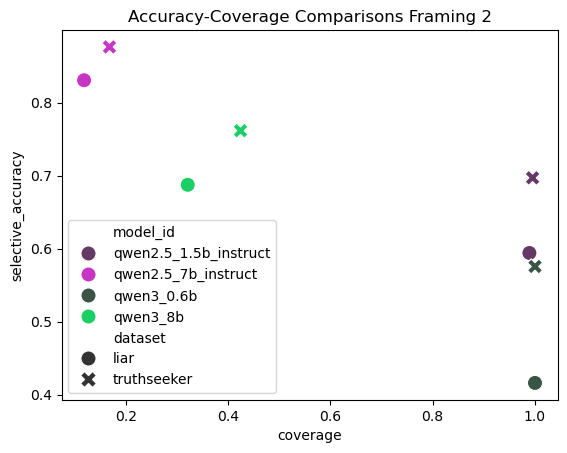

In [10]:
abs_summary = (
    abstain_df
    .groupby(["model_id","dataset"])
    .agg(
        selective_accuracy=("bin_result", "mean"),
        effective_accuracy=("effective_accuracy", "mean"),
        coverage=("valid", "mean")))

sns.scatterplot(
    data=abs_summary.reset_index(),
    style="dataset",
    palette = model_palette,
    x="coverage",
    y="selective_accuracy",
    hue="model_id",
    s=120
)
plt.title("Accuracy-Coverage Comparisons Framing 2")
plt.show()

In [11]:
# this code filters items that were abstained on by a model, shows the number of items and the accuracy on neutral framing
# essentially, it looks at if a model abstaining is justified - if it hadn't abstained, how many of those items would it have gotten rihgt?
# while we can also look at general accuracy of framing 0 vs framing 2 for this, this approach filters out the items a model is confident about
# allowing us to infer how well they evaluate their own accuracy

abstained_items = (
    df
    .query("framing == 'framing2' and abstain == 1")
    [["model_id", "item_id"]]
)

framing0 = df[df["framing"] == "framing0"]

f0_on_abs = framing0.merge(
    abstained_items,
    on=["model_id", "item_id"],
    how="inner"
)

summary = (
    f0_on_abs
    .groupby("model_id")
    .agg(
        control_accuracy_on_abstained=("bin_result", "mean"),
        n_items=("item_id", "nunique")
    )
    .reset_index()
)

print(summary)

# prints the following:
#                 model_id  control_accuracy_on_abstained  n_items
# 0  qwen2.5_1.5b_instruct                       0.636364       11
# 1    qwen2.5_7b_instruct                       0.556126     1363
# 2               qwen3_8b                       0.579001      981

# 1 model did not abstain once, and of the ones that did, they had generally low accuracy (close to chance) on the ones that they abstained on
# this implies at least a limited ability to approximate their own likely accuracy on an item before answered

                model_id  control_accuracy_on_abstained  n_items
0  qwen2.5_1.5b_instruct                       0.636364       11
1    qwen2.5_7b_instruct                       0.556126     1363
2               qwen3_8b                       0.579001      981


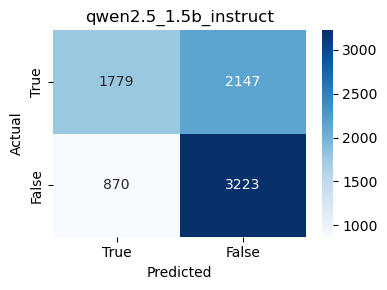

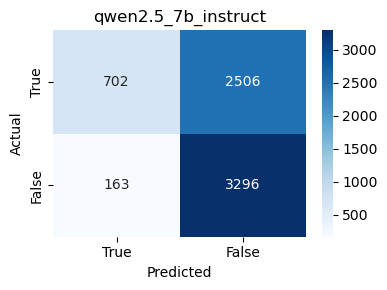

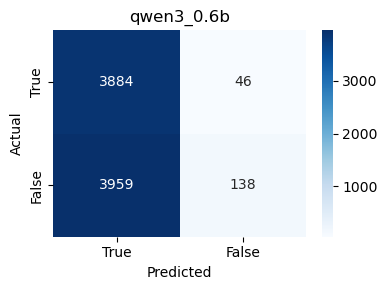

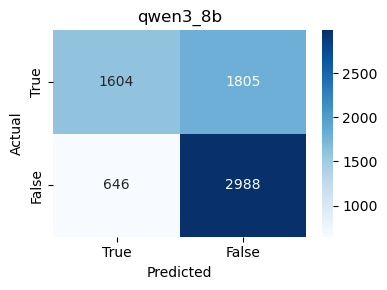

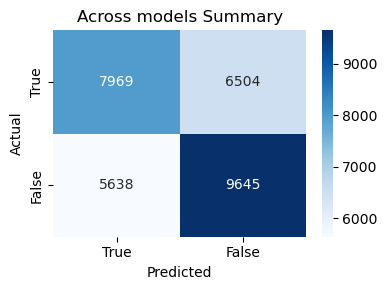

In [12]:
models = valid_df["model_id"].unique()

for m in models:
    sub = valid_df[valid_df["model_id"] == m]

    cm = confusion_matrix(sub["target"], sub["prediction"], labels=[1,0])

    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["True", "False"],
        yticklabels=["True", "False"]
    )

    plt.title(m)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

#summary plot
cm = confusion_matrix(valid_df["target"], valid_df["prediction"], labels=[1,0])


plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["True", "False"],
    yticklabels=["True", "False"]
)

plt.title("Across models Summary")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
#only the non-instruct small model had the most common error be false positives

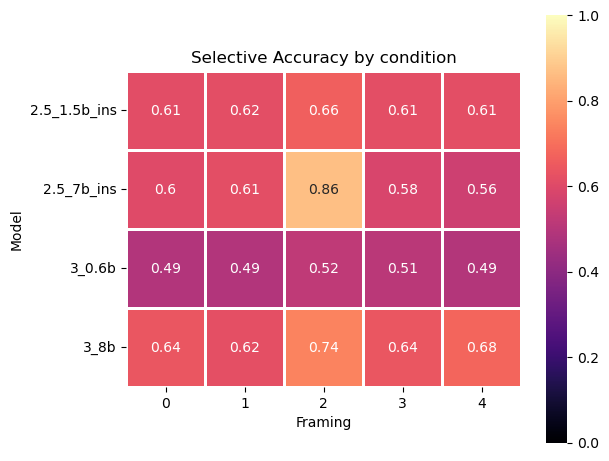

In [13]:
#summary of models against framings by selective accuracy
summary = (
    vis_df
    .groupby(["model_id", "framing"])
    .agg(selective_accuracy=("bin_result", "mean"),
         ).reset_index()
    )

heatmap_data = summary.pivot(
    index="model_id",
    columns="framing",
    values="selective_accuracy"
)

sns.heatmap(
    heatmap_data,
    vmin = 0,
    vmax = 1,
    annot=True,
    cmap="magma",
    square = True,
    linewidths= 1
)

plt.title("Selective Accuracy by condition")
plt.xlabel("Framing")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

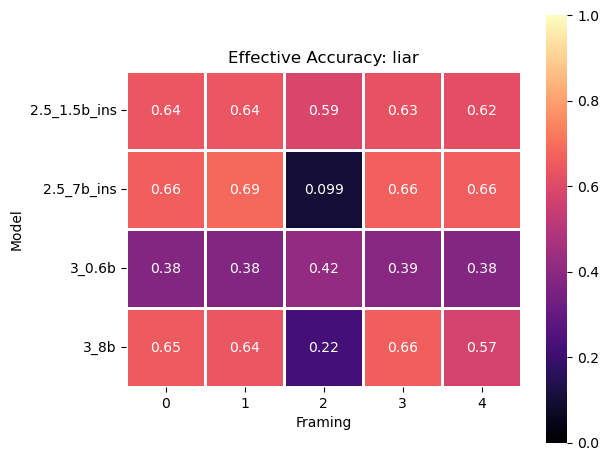

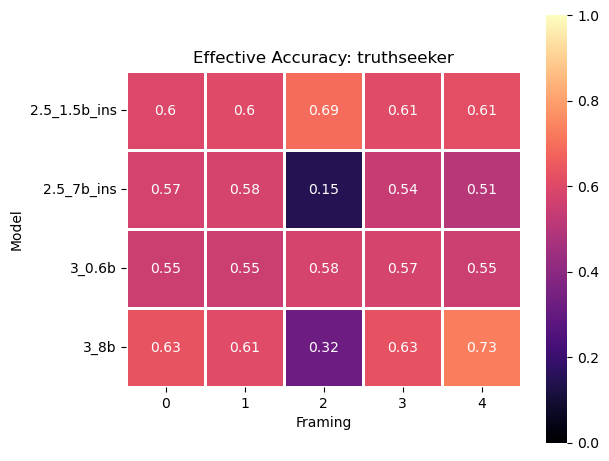

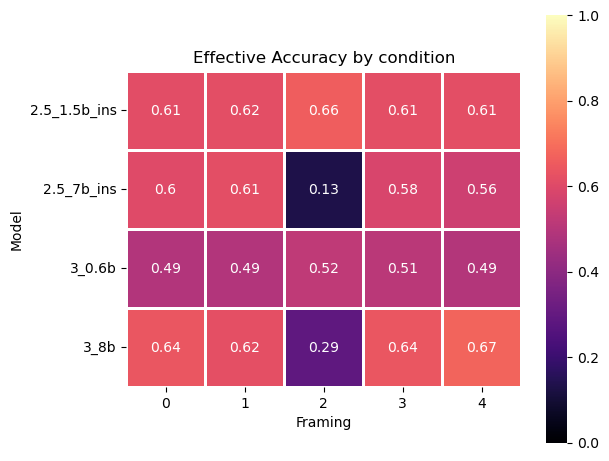

In [14]:
for d in vis_df["dataset"].unique():
    sub = vis_df[vis_df["dataset"] == d]
    summary = (
    sub
    .groupby(["model_id", "framing"])
    .agg(
        eff_acc=("effective_accuracy", "mean"), #effective accuracy
    ))

    vals = np.reshape(summary.values, [len(vis_df["model_id"].unique()), len(vis_df["framing"].unique())]) # rows = models, cols = framing

    sns.heatmap(
        vals,
        vmin = 0,
        vmax = 1,
        annot=True,
        yticklabels=vis_df["model_id"].unique(),
        cmap="magma",
        square = True,
        linewidths= 1
    )

    plt.title(f"Effective Accuracy: {d}")
    plt.xlabel("Framing")
    plt.ylabel("Model")
    plt.tight_layout()
    plt.show()

#summary of models against framings by effective accuracy
summary = (
    vis_df
    .groupby(["model_id", "framing"])
    .agg(
        eff_acc=("effective_accuracy", "mean"), #effective accuracy
    ))

vals = np.reshape(summary.values, [len(vis_df["model_id"].unique()), len(vis_df["framing"].unique())]) # rows = models, cols = framing

sns.heatmap(
    vals,
    vmin = 0,
    vmax = 1,
    annot=True,
    cmap="magma",
    square = True,
    yticklabels=vis_df["model_id"].unique(),
    linewidths= 1
)

plt.title("Effective Accuracy by condition")
plt.xlabel("Framing")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [15]:
# number of unique answers across framings
consistency = (
    vis_df
    .groupby(["model_id", "item_id"])["bin_result"]
    .agg(
        n_unique="nunique",
        n_total="count"
    )
    .reset_index()
)

consistency["consistent"] = consistency["n_unique"] == 1

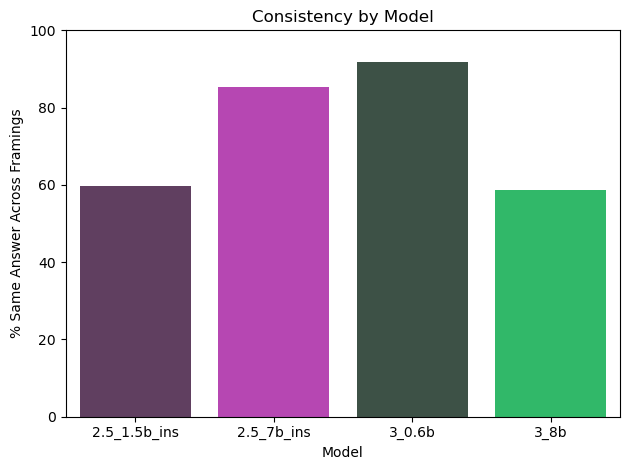

In [16]:
summary = (
    consistency
    .groupby("model_id")["consistent"]
    .mean()
    .mul(100)
    .reset_index(name="pct_consistent")
)

sns.barplot(
    data=summary,
    x="model_id",
    y="pct_consistent",
    hue="model_id",
    palette=model_palette,
    legend=False
)

plt.title("Consistency by Model")
plt.ylabel("% Same Answer Across Framings")
plt.xlabel("Model")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [17]:
def agreement_score(x): #returns highest proportion of framings that agree on an item
    return x.value_counts(normalize=True).max()

agreement = (
    vis_df
    .groupby(["model_id", "item_id"])["bin_result"]
    .apply(agreement_score)
    .reset_index(name="agreement")
)

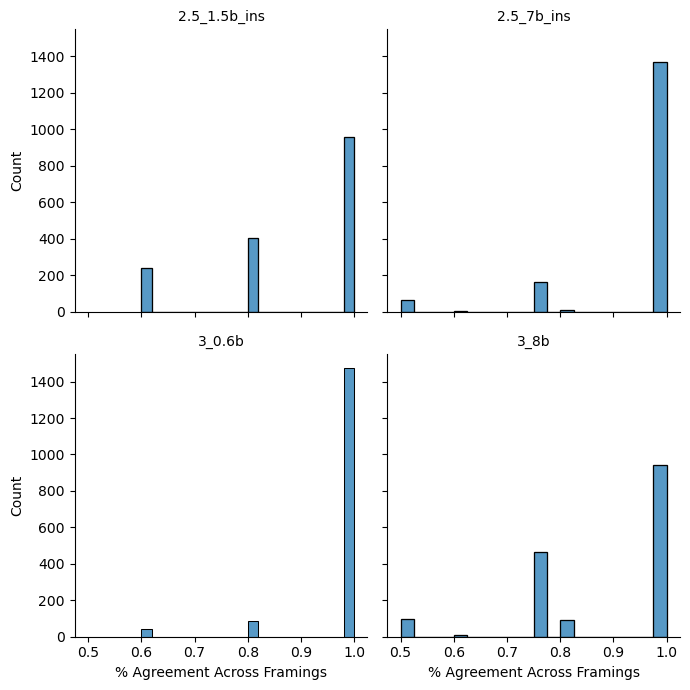

In [18]:
agree = sns.FacetGrid(
    agreement,
    col="model_id",
    col_wrap=2,
    sharex=True,
    sharey=True,
    height=3.5
)

agree.map_dataframe(
    sns.histplot,
    x="agreement",
    bins=20
)

agree.set_axis_labels("% Agreement Across Framings", "Count")
agree.set_titles("{col_name}")

plt.tight_layout()
plt.show()